In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/retail_cleaned.csv", parse_dates=["InvoiceDate"])

# 设定分析基准日期（数据最后一天的下一天）
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"基准日期：{snapshot_date.date()}")
print(f"客户数：{df['Customer ID'].nunique():,}")

基准日期：2011-12-10
客户数：5,878


## 计算 RFM 指标
- **Recency**：最后一次购买距基准日的天数（越小越好）
- **Frequency**：购买次数（越大越好）
- **Monetary**：总消费金额（越大越好）

In [2]:
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
)

print(rfm.describe().round(1))

       Recency  Frequency  Monetary
count   5878.0     5878.0    5878.0
mean     201.3        6.3    3018.6
std      209.3       13.0   14737.7
min        1.0        1.0       3.0
25%       26.0        1.0     348.8
50%       96.0        3.0     898.9
75%      380.0        7.0    2307.1
max      739.0      398.0  608821.6


In [3]:
# 对 R/F/M 各打 1-5 分（用分位数切分）
# Recency 越小越好，所以分数要反转（labels 倒序）
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])

# 组合成 RFM 分数字符串
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

print("打分结果示例：")
print(rfm.head(10))

打分结果示例：
             Recency  Frequency  Monetary R_score F_score M_score RFM_score
Customer ID                                                                
12346            326         12  77556.46       2       5       5       255
12347              2          8   5633.32       5       4       5       545
12348             75          5   2019.40       3       4       4       344
12349             19          4   4428.69       5       3       5       535
12350            310          1    334.40       2       1       2       212
12351            375          1    300.93       2       1       2       212
12352             36         10   2849.84       4       5       4       454
12353            204          2    406.76       2       2       2       222
12354            232          1   1079.40       2       1       3       213
12355            214          2    947.61       2       2       3       223


In [4]:
def rfm_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])
    
    if r >= 4 and f >= 4 and m >= 4:
        return "高价值忠诚客户"
    elif r >= 4 and f >= 4 and m <= 3:
        return "高频低消客户"
    elif r >= 4 and f <= 2:
        return "新客户"
    elif r <= 2 and f >= 4 and m >= 4:
        return "流失风险高价值"
    elif r <= 2 and f >= 4 and m <= 3:
        return "流失风险一般价值"
    elif r >= 3 and f >= 3 and m >= 3:
        return "潜力客户"
    elif r <= 2 and f <= 2:
        return "沉睡客户"
    else:
        return "一般客户"

rfm["用户标签"] = rfm.apply(rfm_segment, axis=1)

seg_count = rfm["用户标签"].value_counts()
seg_revenue = rfm.groupby("用户标签")["Monetary"].sum().sort_values(ascending=False)

print("=== 各群体人数 ===")
print(seg_count)
print(f"\n=== 各群体总收入 ===")
print(seg_revenue.apply(lambda x: f"£{x:,.0f}"))

=== 各群体人数 ===
用户标签
沉睡客户        1523
高价值忠诚客户     1300
一般客户        1102
潜力客户         975
新客户          443
流失风险高价值      227
高频低消客户       182
流失风险一般价值     126
Name: count, dtype: int64

=== 各群体总收入 ===
用户标签
高价值忠诚客户     £12,128,116
潜力客户         £2,449,266
流失风险高价值      £1,018,867
一般客户           £813,033
沉睡客户           £667,122
新客户            £394,639
高频低消客户         £165,023
流失风险一般价值       £107,364
Name: Monetary, dtype: str


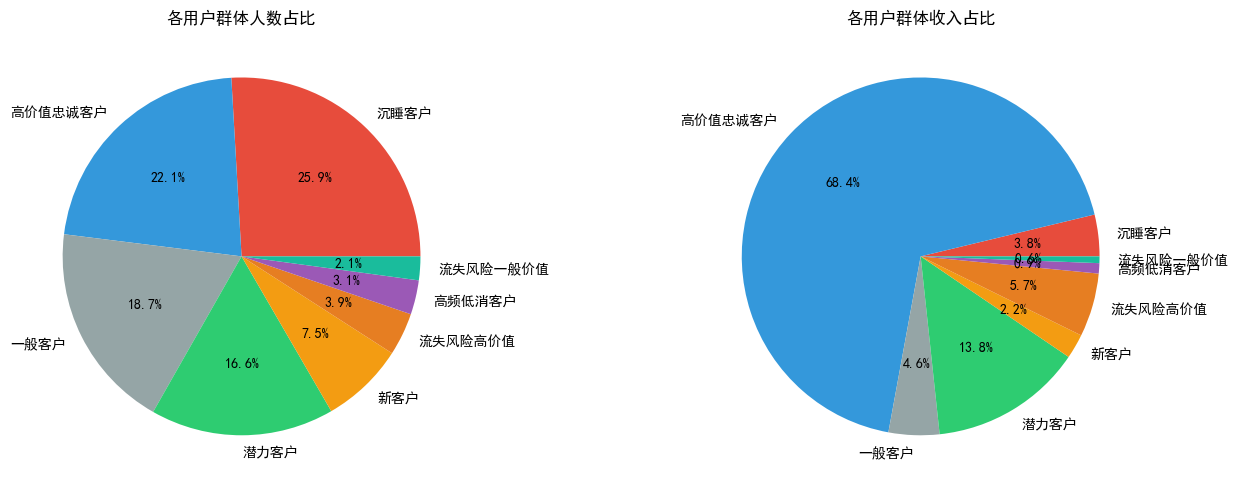

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：人数占比
colors = ['#e74c3c', '#3498db', '#95a5a6', '#2ecc71', '#f39c12', '#e67e22', '#9b59b6', '#1abc9c']
axes[0].pie(seg_count, labels=seg_count.index, autopct="%1.1f%%", colors=colors)
axes[0].set_title("各用户群体人数占比")

# 右图：收入占比
seg_revenue_sorted = seg_revenue.loc[seg_count.index]  # 保持顺序一致
axes[1].pie(seg_revenue_sorted, labels=seg_revenue_sorted.index, autopct="%1.1f%%", colors=colors)
axes[1].set_title("各用户群体收入占比")

plt.tight_layout()
plt.show()

## 发现：用户价值高度集中

- **高价值忠诚客户**占 22% 人数，但贡献 68% 收入——这是命脉，必须维护
- **沉睡客户**占 26% 人数，但只有 3.8% 收入——召回的 ROI 可能不高
- **流失风险高价值**只有 227 人（3.9%），但贡献 5.7% 收入——这批人最值得投入资源召回
- **潜力客户**16.6% 人数贡献 13.8% 收入——最有可能转化为高价值客户的群体

In [7]:
rfm.to_csv("../data/rfm_result.csv")
print(f"已保存 {len(rfm)} 个客户的 RFM 分层结果")

已保存 5878 个客户的 RFM 分层结果
